<a href="https://colab.research.google.com/github/SohanKumar56/23102A0056_RPROGRAMMING/blob/main/LAB6_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sohan Kumar

Branch: CMPN-A

Roll no.: 23102A0056

# Statistical Analysis of Physical Characteristics of Palmer Penguins

## 1. INSTALL AND LOAD REQUIRED PACKAGES

In [30]:

install.packages(c(
  "palmerpenguins",
  "ggplot2",
  "dplyr",
  "moments",
  "car",
  "effsize"
), repos = "https://cloud.r-project.org")

library(palmerpenguins)
library(ggplot2)
library(dplyr)
library(moments)
library(car)
library(effsize)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




## 2. LOAD DATASET

In [31]:
data("penguins")

# View first few rows
head(penguins)

# Dataset structure
str(penguins)

# Number of observations
nrow(penguins)

# Summary
summary(penguins)

# Remove missing values for analysis
penguins_clean <- penguins %>%
  filter(
    !is.na(body_mass_g),
    !is.na(flipper_length_mm),
    !is.na(sex),
    !is.na(species)
  )

cat("Number of complete observations:", nrow(penguins_clean), "\n")

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


[1] 344

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

Number of complete observations: 333 


## TASK 1: DESCRIPTIVE STATISTICAL ANALYSIS

### Overall descriptive statistics for body mass

In [33]:
body_mass <- penguins_clean$body_mass_g

cat("\n===== OVERALL BODY MASS STATISTICS =====\n")

cat("Mean:", mean(body_mass), "\n")
cat("Median:", median(body_mass), "\n")
cat("Minimum:", min(body_mass), "\n")
cat("Maximum:", max(body_mass), "\n")
cat("Variance:", var(body_mass), "\n")
cat("Standard Deviation:", sd(body_mass), "\n")
cat("First Quartile:", quantile(body_mass, 0.25), "\n")
cat("Third Quartile:", quantile(body_mass, 0.75), "\n")
cat("IQR:", IQR(body_mass), "\n")
cat("Skewness:", skewness(body_mass), "\n")
cat("Kurtosis:", kurtosis(body_mass), "\n")


===== OVERALL BODY MASS STATISTICS =====
Mean: 4207.057 
Median: 4050 
Minimum: 2700 
Maximum: 6300 
Variance: 648372.5 
Standard Deviation: 805.2158 
First Quartile: 3550 
Third Quartile: 4775 
IQR: 1225 
Skewness: 0.4701162 
Kurtosis: 2.259514 


### Descriptive statistics separately by species

In [34]:

species_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Count = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

print(species_stats)

# A tibble: 3 × 13
  species   Count  Mean Median Minimum Maximum Variance    SD    Q1    Q3   IQR
  <fct>     <int> <dbl>  <dbl>   <int>   <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie      146 3706.   3700    2850    4775  210332.  459. 3362.  4000  638.
2 Chinstrap    68 3733.   3700    2700    4800  147713.  384. 3488.  3950  462.
3 Gentoo      119 5092.   5050    3950    6300  251478.  501. 4700   5500  800 
# ℹ 2 more variables: Skewness <dbl>, Kurtosis <dbl>


### Histogram

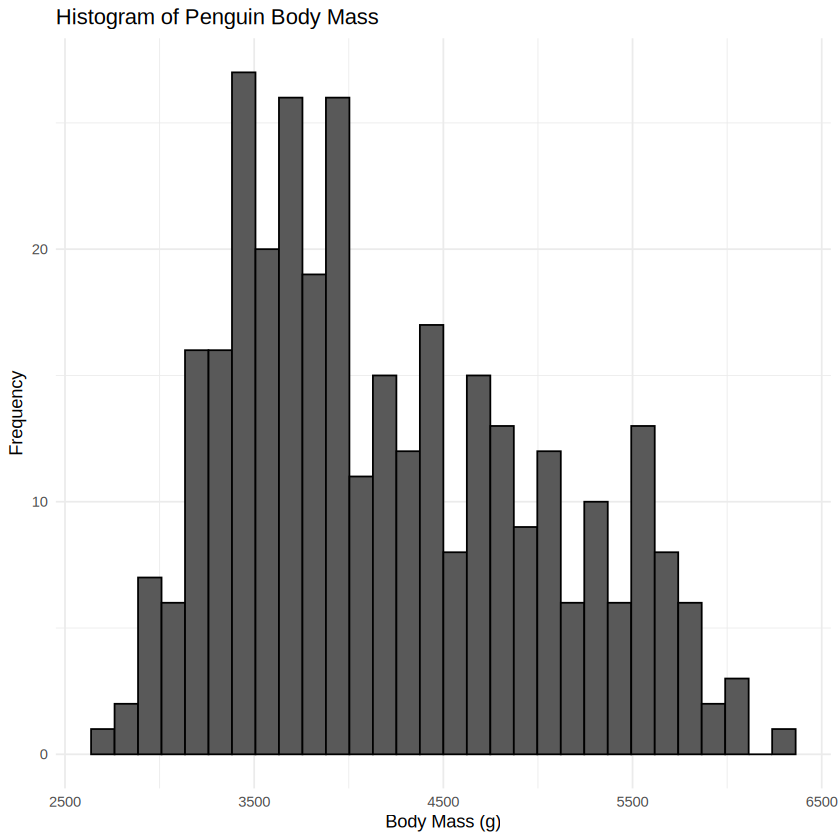

In [35]:

ggplot(penguins_clean, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

### Species-wise boxplot

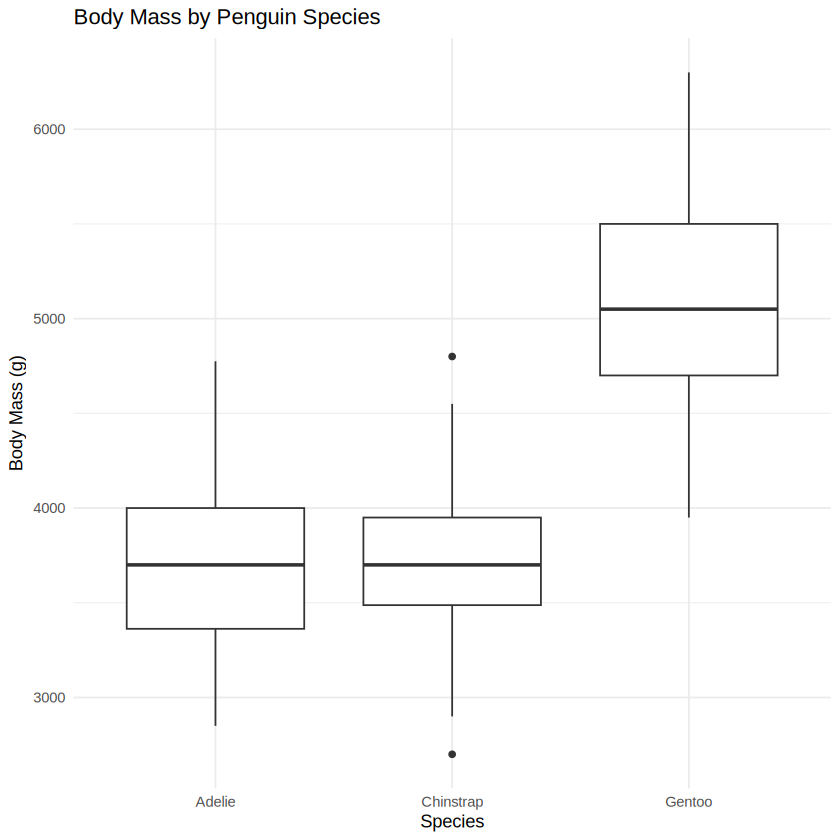

In [36]:
ggplot(penguins_clean,
       aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

### Density plot

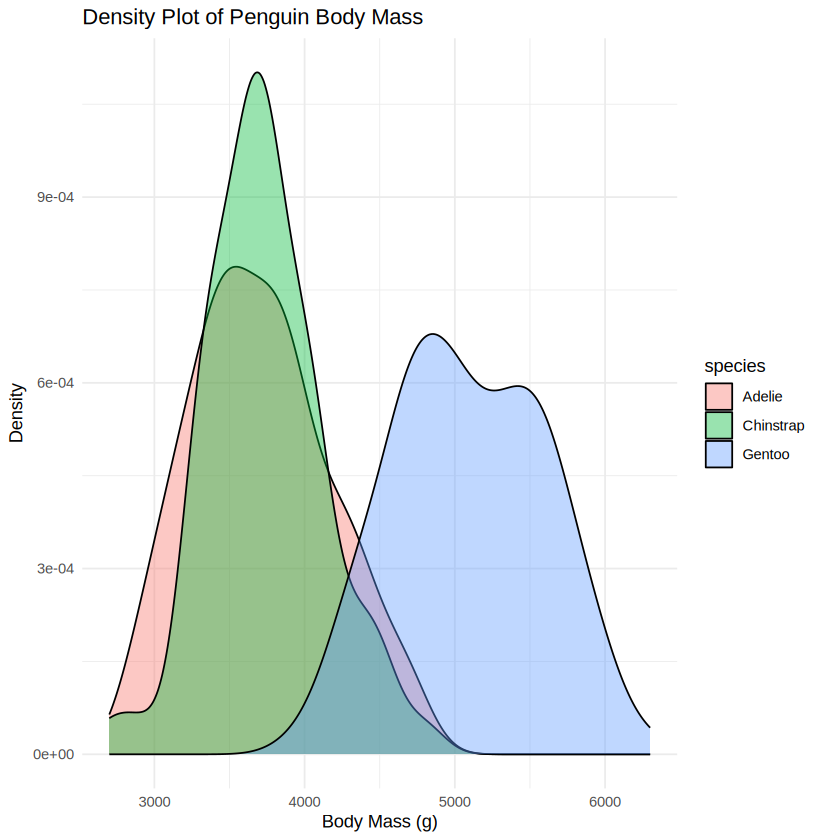

In [37]:
ggplot(penguins_clean,
       aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Density"
  ) +
  theme_minimal()

## TASK 2: HYPOTHESIS TESTING
### Male vs Female Body Mass

### Hypotheses

In [38]:
cat("\n===== HYPOTHESIS TEST =====\n")
cat("H0: Mean male body mass = Mean female body mass\n")
cat("H1: Mean male body mass != Mean female body mass\n")


===== HYPOTHESIS TEST =====
H0: Mean male body mass = Mean female body mass
H1: Mean male body mass != Mean female body mass


### Separate male and female data

In [39]:
male <- penguins_clean %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female <- penguins_clean %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

### Shapiro-Wilk normality test

In [40]:
cat("\n===== SHAPIRO-WILK TEST =====\n")

shapiro_male <- shapiro.test(male)
shapiro_female <- shapiro.test(female)

print(shapiro_male)
print(shapiro_female)


===== SHAPIRO-WILK TEST =====

	Shapiro-Wilk normality test

data:  male
W = 0.92504, p-value = 1.227e-07


	Shapiro-Wilk normality test

data:  female
W = 0.91931, p-value = 6.155e-08



### QQ plots

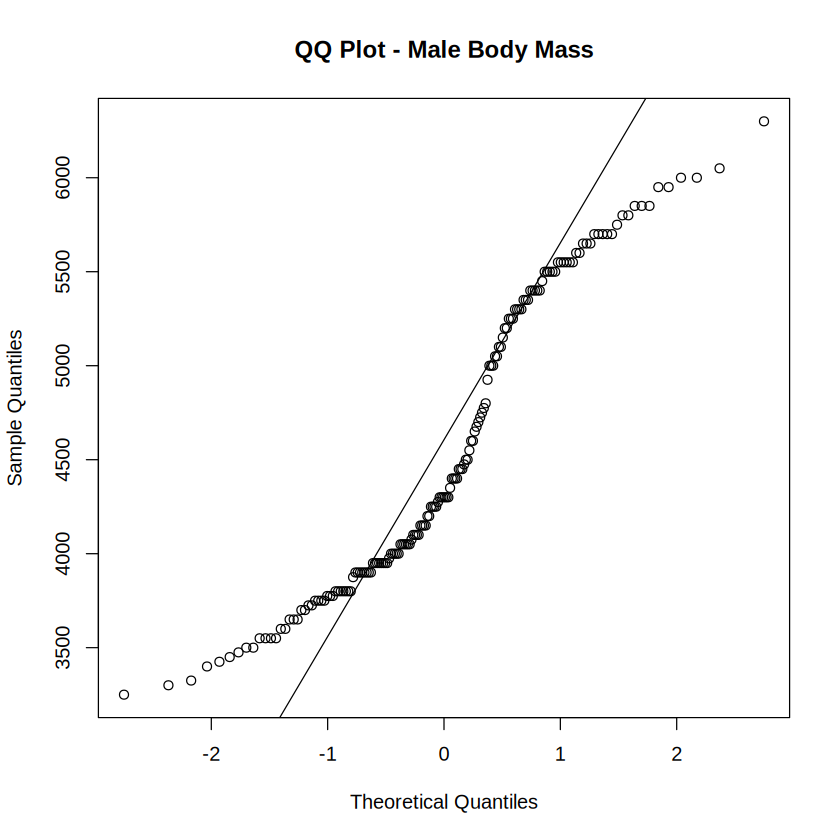

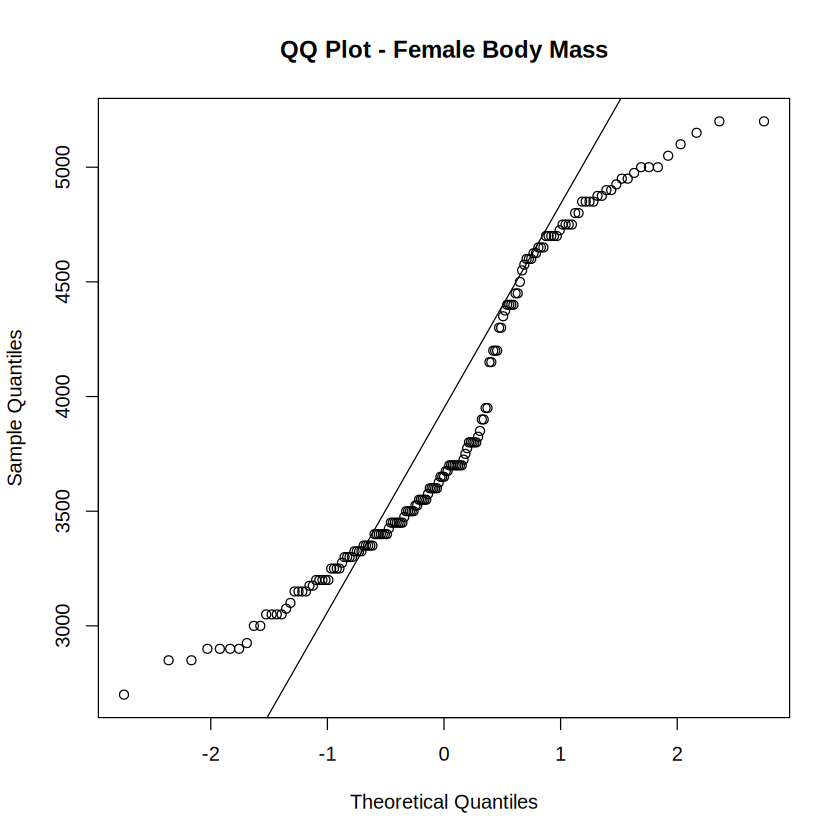

In [41]:
qqnorm(male,
       main = "QQ Plot - Male Body Mass")
qqline(male)

qqnorm(female,
       main = "QQ Plot - Female Body Mass")
qqline(female)

### Independent two-sample t-test
### Welch's t-test

In [42]:
t_test <- t.test(
  male,
  female,
  var.equal = FALSE,
  conf.level = 0.95
)

cat("\n===== INDEPENDENT TWO-SAMPLE T-TEST =====\n")
print(t_test)


===== INDEPENDENT TWO-SAMPLE T-TEST =====

	Welch Two Sample t-test

data:  male and female
t = 8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 526.2453 840.5783
sample estimates:
mean of x mean of y 
 4545.685  3862.273 



### Cohen's d

In [43]:
cohen_result <- cohen.d(
  male,
  female,
  hedges.correction = TRUE
)

cat("\n===== COHEN'S D =====\n")
print(cohen_result)


===== COHEN'S D =====

Hedges's g

g estimate: 0.9340819 (large)
95 percent confidence interval:
    lower     upper 
0.7075366 1.1606272 



### Sex-wise boxplot

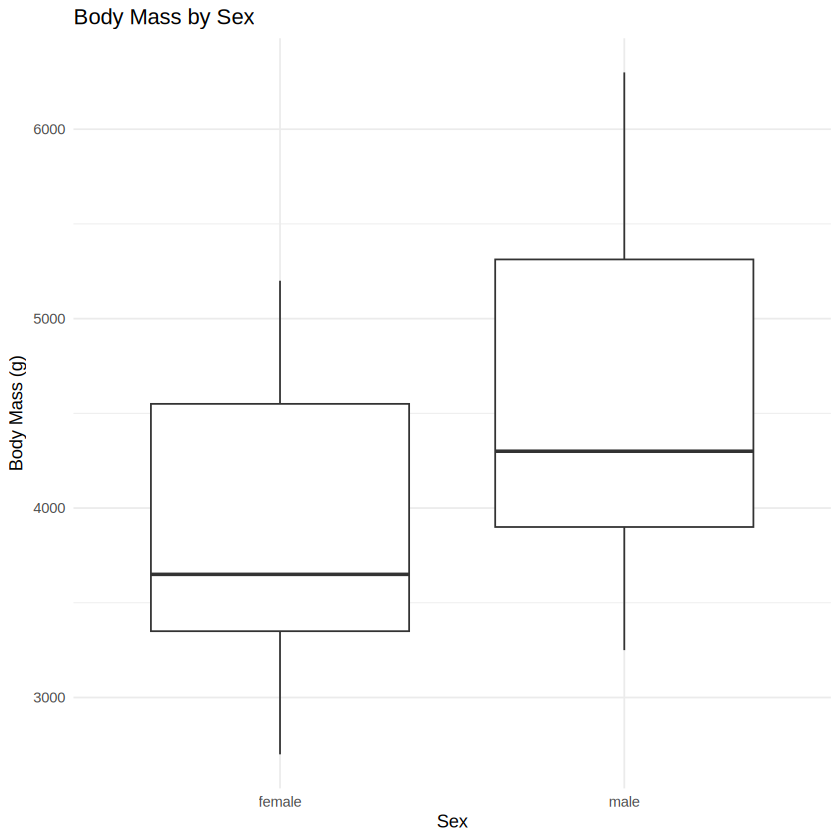

In [44]:
ggplot(penguins_clean,
       aes(x = sex, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

## TASK 3: ONE-WAY ANOVA
### Body Mass ~ Species

### Examine distribution by species

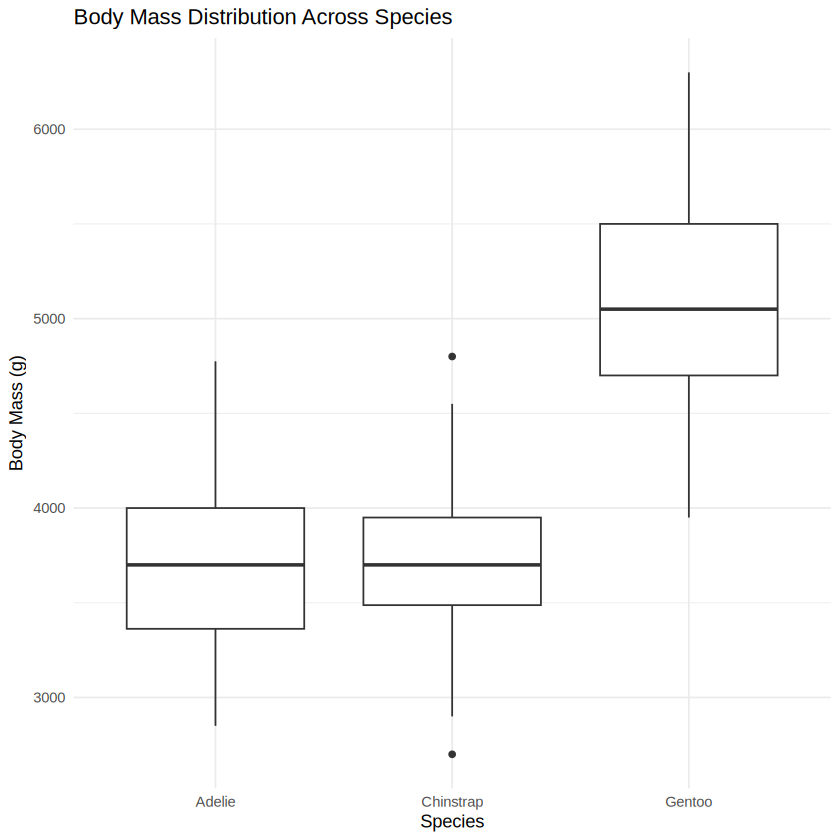

In [45]:
ggplot(penguins_clean,
       aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  labs(
    title = "Body Mass Distribution Across Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

### Shapiro-Wilk test for each species

In [46]:
cat("\n===== SPECIES-WISE SHAPIRO TESTS =====\n")

by(penguins_clean$body_mass_g,
   penguins_clean$species,
   shapiro.test)


===== SPECIES-WISE SHAPIRO TESTS =====


penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


### ANOVA model

In [47]:
anova_model <- aov(
  body_mass_g ~ species,
  data = penguins_clean
)

cat("\n===== ONE-WAY ANOVA =====\n")
summary(anova_model)


===== ONE-WAY ANOVA =====


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Levene's Test

In [48]:
cat("\n===== LEVENE'S TEST =====\n")

levene_result <- leveneTest(
  body_mass_g ~ species,
  data = penguins_clean
)

print(levene_result)


===== LEVENE'S TEST =====
Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Tukey HSD Post-Hoc Test


===== TUKEY HSD TEST =====
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



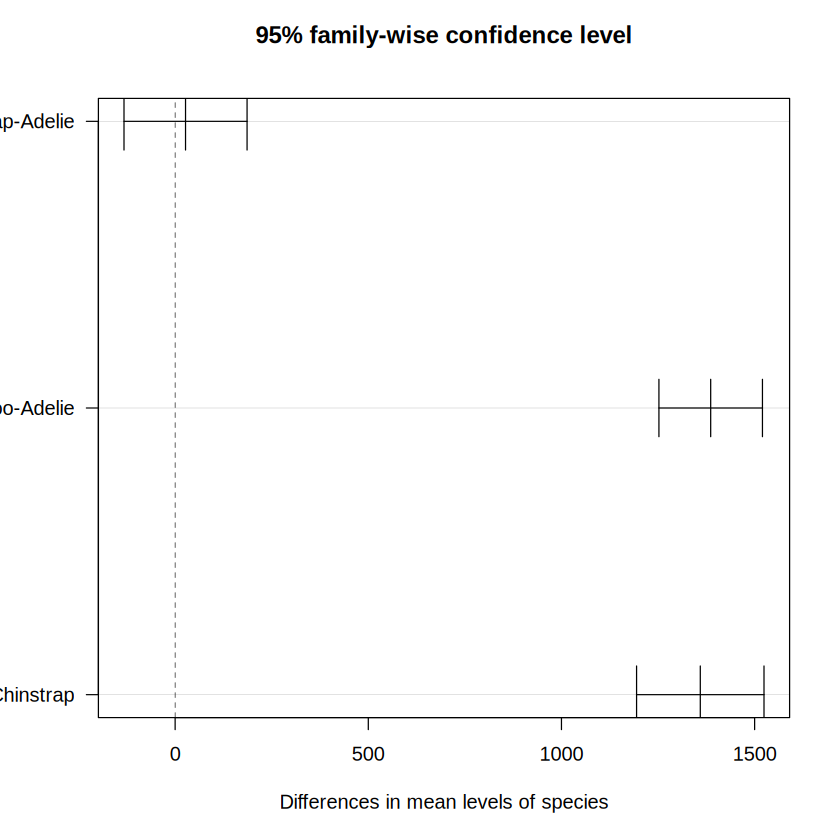

In [49]:
cat("\n===== TUKEY HSD TEST =====\n")

tukey_result <- TukeyHSD(anova_model)

print(tukey_result)


# Tukey plot
plot(
  tukey_result,
  las = 1
)

## TASK 4: KRUSKAL-WALLIS TEST

In [50]:
cat("\n===== KRUSKAL-WALLIS TEST =====\n")

kruskal_result <- kruskal.test(
  body_mass_g ~ species,
  data = penguins_clean
)

print(kruskal_result)


===== KRUSKAL-WALLIS TEST =====

	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16



## TASK 5: TWO-WAY ANOVA
### Body Mass ~ Species * Sex

In [51]:
cat("\n===== TWO-WAY ANOVA =====\n")

two_way_model <- aov(
  body_mass_g ~ species * sex,
  data = penguins_clean
)

summary(two_way_model)


===== TWO-WAY ANOVA =====


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Interaction plot

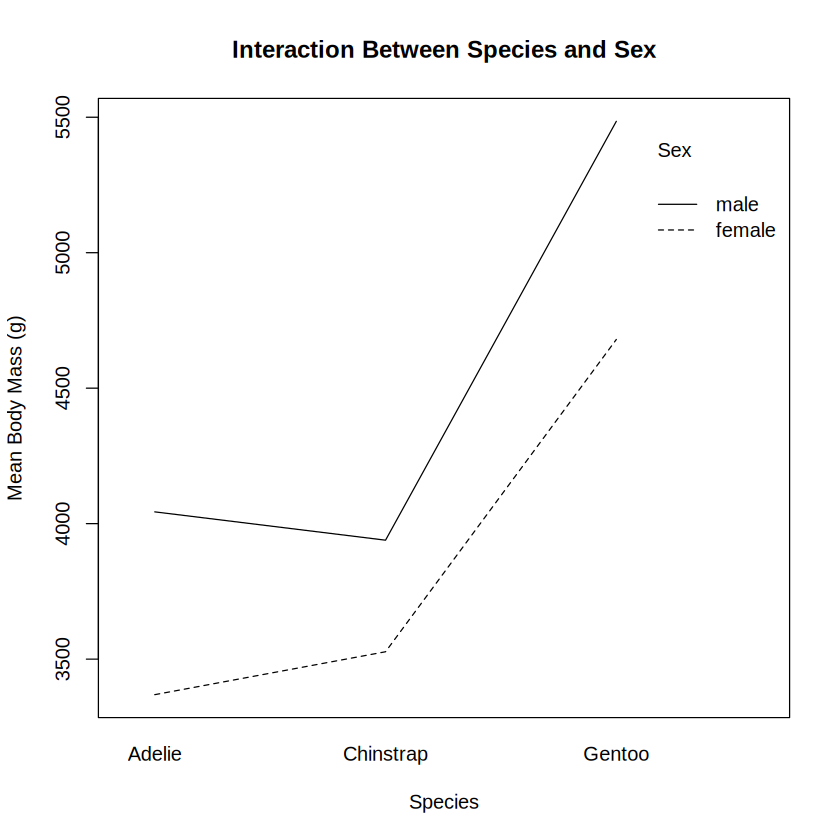

In [52]:
interaction.plot(
  penguins_clean$species,
  penguins_clean$sex,
  penguins_clean$body_mass_g,
  xlab = "Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Interaction Between Species and Sex"
)

### Two-way ANOVA boxplot

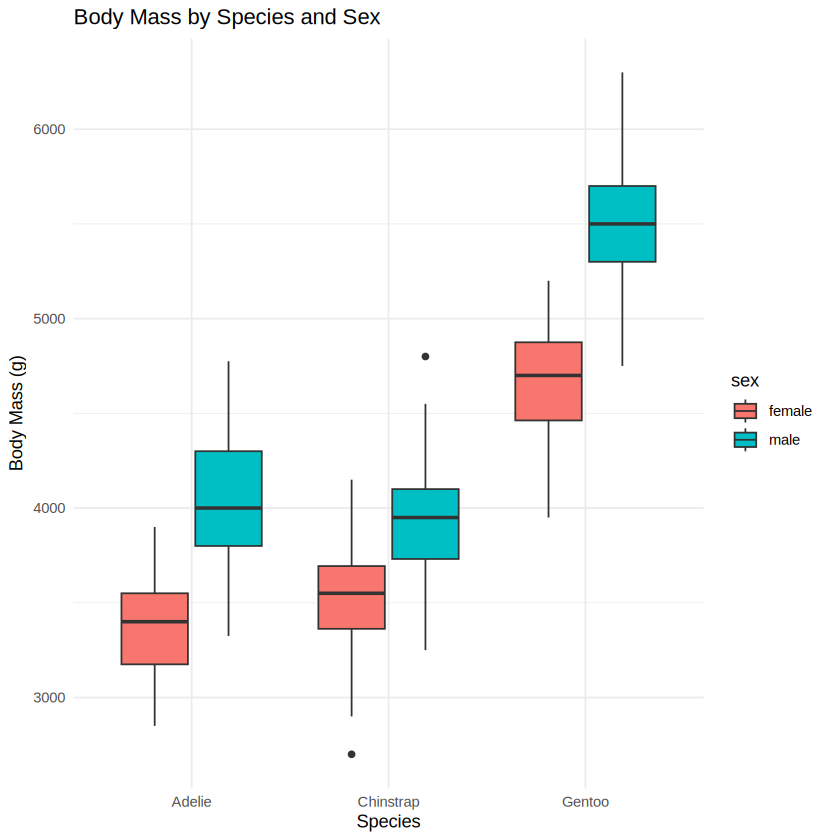

In [53]:
ggplot(
  penguins_clean,
  aes(x = species,
      y = body_mass_g,
      fill = sex)
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

## TASK 6: FLIPPER LENGTH ANALYSIS

In [54]:
cat("\n===== FLIPPER LENGTH ANALYSIS =====\n")

# Descriptive statistics
flipper_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Count = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm)
  )

print(flipper_stats)


===== FLIPPER LENGTH ANALYSIS =====
# A tibble: 3 × 8
  species   Count  Mean Median    SD Minimum Maximum   IQR
  <fct>     <int> <dbl>  <dbl> <dbl>   <int>   <int> <dbl>
1 Adelie      146  190.    190  6.52     172     210   9  
2 Chinstrap    68  196.    196  7.13     178     212  10  
3 Gentoo      119  217.    216  6.59     203     231   9.5


### Flipper length boxplot

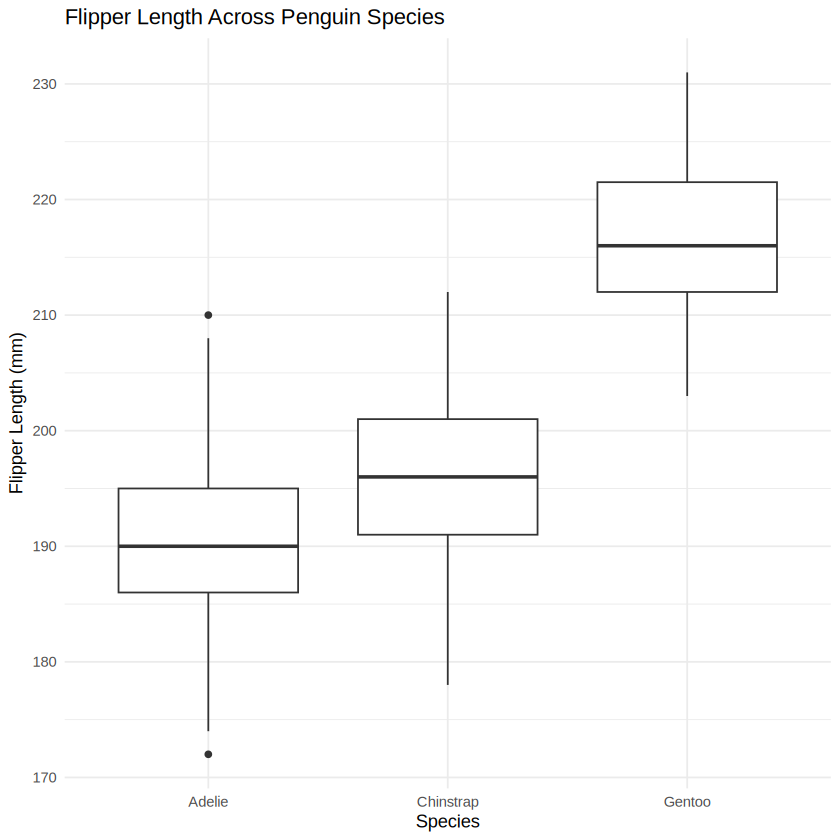

In [55]:
ggplot(
  penguins_clean,
  aes(
    x = species,
    y = flipper_length_mm
  )
) +
  geom_boxplot() +
  labs(
    title = "Flipper Length Across Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

### ANOVA for flipper length

In [56]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = penguins_clean
)

cat("\n===== FLIPPER LENGTH ANOVA =====\n")
summary(flipper_anova)


===== FLIPPER LENGTH ANOVA =====


             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Tukey test for flipper length

In [57]:
cat("\n===== FLIPPER LENGTH TUKEY TEST =====\n")

flipper_tukey <- TukeyHSD(flipper_anova)

print(flipper_tukey)


===== FLIPPER LENGTH TUKEY TEST =====
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0



## TASK 7: SUMMARY OF RESULTS

In [58]:
cat("\n============================================\n")
cat("           FINAL ANALYSIS SUMMARY\n")
cat("============================================\n")

cat("\n1. Overall mean body mass:",
    mean(body_mass), "grams\n")

cat("\n2. Male mean body mass:",
    mean(male), "grams\n")

cat("3. Female mean body mass:",
    mean(female), "grams\n")

cat("\n4. T-test p-value:",
    t_test$p.value, "\n")

cat("5. Cohen's d:",
    cohen_result$estimate, "\n")

cat("\n6. One-way ANOVA p-value:",
    summary(anova_model)[[1]][["Pr(>F)"]][1], "\n")

cat("\n7. Kruskal-Wallis p-value:",
    kruskal_result$p.value, "\n")

cat("\n8. Flipper length ANOVA p-value:",
    summary(flipper_anova)[[1]][["Pr(>F)"]][1], "\n")

cat("\n============================================\n")
cat("Analysis Completed Successfully!\n")
cat("============================================\n")


           FINAL ANALYSIS SUMMARY

1. Overall mean body mass: 4207.057 grams

2. Male mean body mass: 4545.685 grams
3. Female mean body mass: 3862.273 grams

4. T-test p-value: 4.793891e-16 
5. Cohen's d: 0.9340819 

6. One-way ANOVA p-value: 3.744505e-81 

7. Kruskal-Wallis p-value: 8.836877e-47 

8. Flipper length ANOVA p-value: 1.587418e-107 

Analysis Completed Successfully!
